# Video Game Sales Analysis

## Data Inspection

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/vgsales.csv")

### Review Dataset

In [3]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,NA_Units,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,0.0,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,0.0,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,0.0,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,0.0,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,0.0,8.89,10.22,1.00,31.37


In [4]:
df.shape

(16600, 12)

In [5]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'NA_Units', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16600 entries, 0 to 16599
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16600 non-null  int64  
 1   Name          16583 non-null  str    
 2   Platform      16578 non-null  str    
 3   Year          16329 non-null  float64
 4   Genre         16584 non-null  str    
 5   Publisher     16524 non-null  str    
 6   NA_Sales      16599 non-null  float64
 7   NA_Units      16594 non-null  float64
 8   EU_Sales      16593 non-null  float64
 9   JP_Sales      16593 non-null  float64
 10  Other_Sales   16023 non-null  float64
 11  Global_Sales  16593 non-null  float64
dtypes: float64(7), int64(1), str(4)
memory usage: 1.5 MB


### Check for missing and duplicate data

In [7]:
# Missing Values
df.isnull().sum().sort_values(ascending=False)

Other_Sales     577
Year            271
Publisher        76
Platform         22
Name             17
Genre            16
EU_Sales          7
JP_Sales          7
Global_Sales      7
NA_Units          6
NA_Sales          1
Rank              0
dtype: int64

In [8]:
# Duplicates
df.duplicated().sum()

np.int64(1)

### Statistics and Value Counts

In [9]:
# Summary Statistics
df.describe()

,Rank,Year,NA_Sales,NA_Units,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16600.000000,16329.000000,16599.000000,16594.0,16593.000000,16593.000000,16023.000000,16593.000000
mean,8301.210241,2006.283483,0.264655,0.0,0.146699,0.077793,0.049519,0.537595
std,4792.017387,16.748366,0.816660,0.0,0.505420,0.309337,0.191769,1.555237
min,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.010000
25%,4151.750000,2003.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.060000
50%,8301.500000,2007.000000,0.080000,0.0,0.020000,0.000000,0.010000,0.170000
75%,12450.250000,2010.000000,0.240000,0.0,0.110000,0.040000,0.040000,0.470000
max,16601.000000,2020.000000,41.490000,0.0,29.020000,10.220000,10.570000,82.740000


In [10]:
# How many of each genre
df['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1740
Role-Playing    1488
Shooter         1310
Adventure       1271
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

In [11]:
# How many of each platform
df['Platform'].value_counts()

Platform
PS2     2159
DS      2158
PS3     1328
Wii     1323
X360    1265
PSP     1209
PS      1194
PC       960
XB       824
GBA      822
GC       555
3DS      509
PSV      411
PS4      335
N64      319
SNES     239
XOne     213
SAT      173
WiiU     143
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

In [12]:
# How many from each publisher
df['Publisher'].value_counts().head(10)

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          920
Konami Digital Entertainment     830
THQ                              715
Nintendo                         703
Sony Computer Entertainment      683
Sega                             639
Take-Two Interactive             413
Name: count, dtype: int64

### Sanity check (regional sales vs global sales)

In [13]:
# Sum of regional sales
df["regional_total"] = (df["NA_Sales"]+df["EU_Sales"]+df["JP_Sales"]+df["Other_Sales"])

In [14]:
# Compare to global sales
(df["Global_Sales"] - df["regional_total"]).describe()

count    16023.000000
mean         0.000263
std          0.005272
min         -0.020000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.020000
dtype: float64

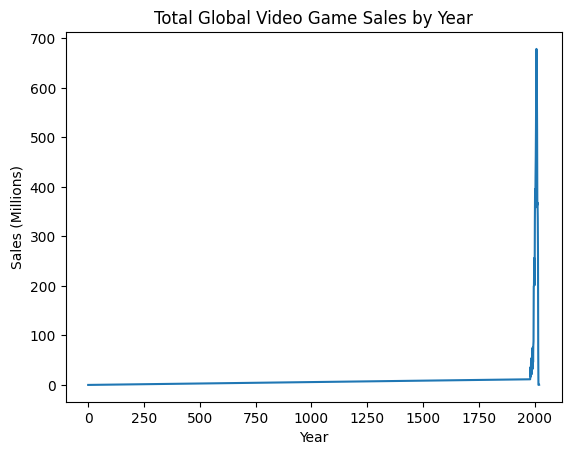

In [15]:
# Quick plot of market
df.groupby("Year")["Global_Sales"].sum().sort_index().plot()
plt.title("Total Global Video Game Sales by Year")
plt.ylabel("Sales (Millions)")
plt.show()

In [16]:
# Year data needs cleaning. Year = 0 shouldnt exist. Omit or impute (if possible)